In [1]:
import sys, pathlib
_here = pathlib.Path.cwd().resolve()
for _p in [_here, *_here.parents]:
    if (_p / "src" / "ml_textbook").exists():
        sys.path.insert(0, str(_p / "src"))
        break

# 02. データ前処理と特徴量エンジニアリング — モデルより先に効く工程

> 各章は **直感 → 最小限の数式 → scikit-learn 実装 → 可視化 → 実験 → 演習** の順。本文は日本語、コードは英語。

## この章で分かること

- 欠損値・外れ値・スケール・カテゴリ変数の扱い方
- なぜ **スケーリング** が距離ベース/勾配ベースのモデルで効くのか
- カテゴリの **one-hot vs ordinal** の使い分けと落とし穴
- 最重要: **前処理は訓練データだけで fit する**。テストに触れた瞬間 **リーク** が起きる
- `Pipeline` + `ColumnTransformer` でリークを「構造的に」防ぐ

> 鉄則: **fit on train, transform on test.** 交差検証では各 fold の訓練側だけで前処理を学習し直す。
> これを手で守るのは難しいので、scikit-learn の `Pipeline` に任せる。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

from ml_textbook import datasets, preprocessing, validation

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

# Titanic-like tabular data: mixed numeric/categorical columns with real missingness.
X, y = datasets.make_titanic_like_dataset(n=600, seed=0)
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked
0,3,female,44.151070,0,1,7.98,C
1,2,male,47.169003,1,0,20.67,S
2,1,male,35.489244,0,0,87.84,S
3,1,male,NaN,1,0,139.53,C
4,3,male,21.249312,1,0,17.44,C


## 1. まずデータを観察する — 型と欠損

前処理の第一歩は「どの列が数値で、どの列がカテゴリで、どこが欠けているか」を把握することです。

In [3]:
numeric, categorical = preprocessing.split_feature_types(X)
print("numeric    :", numeric)
print("categorical:", categorical)
print("\nmissing fraction per column:")
print(X.isna().mean().round(3))

numeric    : ['pclass', 'age', 'sibsp', 'parch', 'fare']
categorical: ['sex', 'embarked']

missing fraction per column:
pclass      0.000
sex         0.000
age         0.202
sibsp       0.000
parch       0.000
fare        0.000
embarked    0.012
dtype: float64


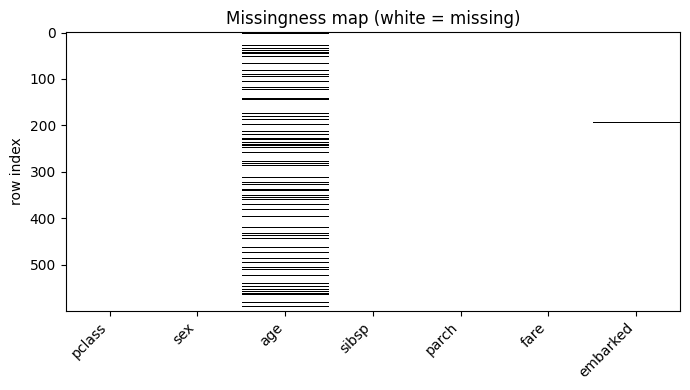

In [4]:
# Missingness map: white cells are missing (age and embarked here).
fig, ax = plt.subplots(figsize=(7, 4))
ax.imshow(X.isna().to_numpy(), aspect="auto", cmap="gray_r", interpolation="nearest")
ax.set_xticks(range(X.shape[1]))
ax.set_xticklabels(X.columns, rotation=45, ha="right")
ax.set_ylabel("row index")
ax.set_title("Missingness map (white = missing)")
plt.tight_layout()
plt.show()

## 2. 欠損値の補完 (imputation)

欠損を含む行を捨てると情報が減り、バイアスも入ります。代わりに **補完** します。

- 数値列: 中央値(median)。外れ値に強い。
- カテゴリ列: 最頻値(most frequent)。

重要なのは、補完に使う統計量(中央値など)を **訓練データから計算する** こと。
テストの中央値を使うのはリークです。`SimpleImputer` を `Pipeline` に入れれば自動でそうなります。

In [5]:
from sklearn.impute import SimpleImputer

# Median imputation learned from the column (inside a pipeline this is train-only).
imputer = SimpleImputer(strategy="median")
age_imputed = imputer.fit_transform(X[["age"]])
print("age missing before:", int(X["age"].isna().sum()), " after:", int(np.isnan(age_imputed).sum()))
print("learned median age:", float(imputer.statistics_[0]).__round__(2))

age missing before: 121  after: 0
learned median age: 28.99


## 3. 外れ値とスケーラの選択

外れ値は **平均・分散** を大きく動かします。だから `StandardScaler`(平均0・分散1)は外れ値に弱く、
`RobustScaler`(中央値・IQR)は強い。下図で、少数の外れ値が標準化後の分布をどう歪めるか見ます。

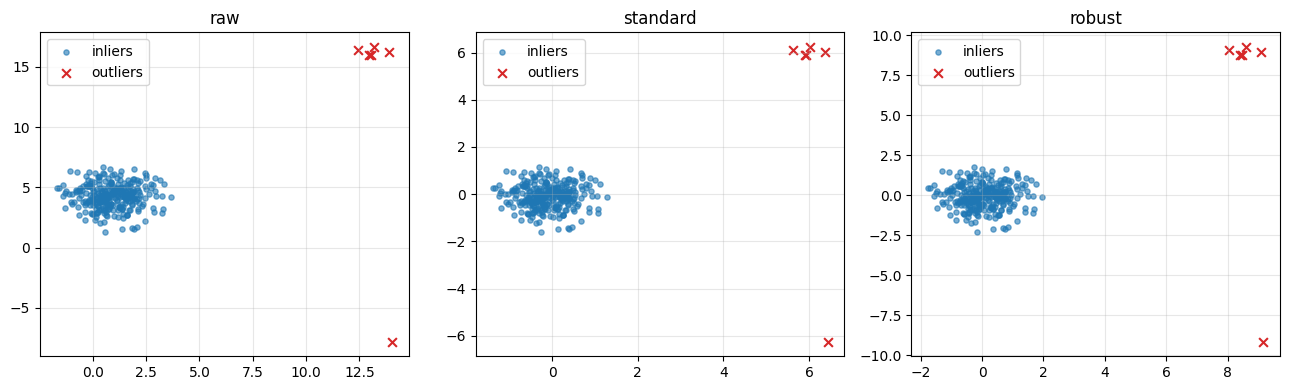

Standard scaling squeezes the inliers into a tiny blob; robust keeps their spread.


In [6]:
# One Gaussian blob with a few extreme outliers injected.
Xb, _ = datasets.make_blobs_dataset(n=300, centers=1, cluster_std=1.0, seed=0)
Xo, out_idx = preprocessing.inject_outliers(Xb, frac=0.02, magnitude=12.0, seed=0)
scaled = preprocessing.compare_scalers(Xo)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, name in zip(axes, ["raw", "standard", "robust"]):
    Z = scaled[name]
    mask = np.zeros(len(Z), bool); mask[out_idx] = True
    ax.scatter(Z[~mask, 0], Z[~mask, 1], s=14, alpha=0.6, label="inliers")
    ax.scatter(Z[mask, 0], Z[mask, 1], s=40, c="#d62728", marker="x", label="outliers")
    ax.set_title(name); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()
print("Standard scaling squeezes the inliers into a tiny blob; robust keeps their spread.")

### インタラクティブ: 外れ値の強さとスケーラの頑健性

外れ値の大きさ(σ)をスライダーで上げると、**標準化(standard)/min-max では内点(inlier)のばらつきが潰れ**、
**robust はほぼ一定**に保たれます。外れ値があるなら RobustScaler、が一目で分かります(静的 HTML 可)。

In [7]:
mags = [0, 2, 4, 8, 16, 32]
scaler_names = ["raw", "standard", "minmax", "robust"]
colors = ["#999999", "#1f77b4", "#ff7f0e", "#2ca02c"]
frames = []
for m in mags:
    Xo_m, idx_m = preprocessing.inject_outliers(Xb, frac=0.02, magnitude=float(m), seed=0)
    inlier = np.ones(len(Xo_m), bool); inlier[idx_m] = False
    scaled_m = preprocessing.compare_scalers(Xo_m)
    spread = [float(scaled_m[name][inlier, 0].std()) for name in scaler_names]
    frames.append(go.Frame(name=str(m), data=[go.Bar(x=scaler_names, y=spread, marker_color=colors)],
                           layout={"title": f"outlier magnitude = {m}σ"}))
fig = go.Figure(data=frames[0].data, frames=frames)
steps = [{"args": [[f.name], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
          "label": f.name, "method": "animate"} for f in frames]
fig.update_layout(sliders=[{"steps": steps, "currentvalue": {"prefix": "magnitude = "}}],
                  title=frames[0].layout.title.text, yaxis_title="inlier spread (std) after scaling",
                  width=620, height=440, margin={"l": 60, "r": 20, "t": 60, "b": 40})
fig.show()

## 4. なぜスケーリングが効くのか

- **距離ベース**(k-NN, SVM, k-means): 大きいスケールの特徴が距離を支配する。
- **勾配ベース / 正則化**(ロジスティック回帰, ニューラルネット): スケールが揃うと収束が速く、罰則が公平。
- **木ベース**(決定木, RF, 勾配ブースティング): 分割は順序しか見ないので **スケール不要**。

桁の違う特徴を持つ Breast Cancer データで、k-NN の精度がスケーリングで跳ね上がることを確認します。

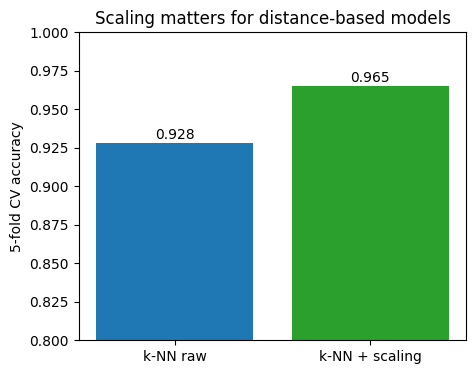

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

bc = datasets.load_breast_cancer_dataset()
Xc, yc = bc.data, bc.target
acc_raw = cross_val_score(KNeighborsClassifier(), Xc, yc, cv=5).mean()
acc_scaled = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier()), Xc, yc, cv=5).mean()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["k-NN raw", "k-NN + scaling"], [acc_raw, acc_scaled], color=["#1f77b4", "#2ca02c"])
ax.set_ylim(0.8, 1.0); ax.set_ylabel("5-fold CV accuracy")
for i, v in enumerate([acc_raw, acc_scaled]):
    ax.text(i, v + 0.003, f"{v:.3f}", ha="center")
ax.set_title("Scaling matters for distance-based models")
plt.show()

## 5. カテゴリ変数のエンコード — one-hot vs ordinal

モデルは数値しか扱えないので、カテゴリを数値化します。

- **One-Hot**: 各カテゴリを 0/1 の列に。順序を仮定しない。**名義尺度の既定**。
- **Ordinal**: A=0, B=1, C=2 のように整数化。**順序がある場合のみ**(low<mid<high など)。

落とし穴: 名義変数(港 S/C/Q など)に ordinal を使うと、モデルは「Q は S の 2 倍」のような
**ありもしない順序** を信じてしまいます。

In [9]:
out = preprocessing.compare_encoders(["S", "S", "C", "Q", "C"])
print("categories:", list(out["categories"]))
print("\none-hot:\n", out["onehot"].astype(int))
print("\nordinal:", out["ordinal"].astype(int), "  <-- invents S<C<Q ordering (wrong for a nominal port!)")

categories: ['C', 'Q', 'S']

one-hot:
 [[0 0 1]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [1 0 0]]

ordinal: [2 2 0 1 0]   <-- invents S<C<Q ordering (wrong for a nominal port!)


## 6. 特徴量の相互作用

線形モデルは単独の特徴しか足し合わせません。$y$ が **特徴の積** に依存する場合、
`PolynomialFeatures` で交互作用項 $x_1 x_2$ を足すと一気に当たるようになります。

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

rng = np.random.default_rng(0)
n = 400
x1 = rng.uniform(-2, 2, n); x2 = rng.uniform(-2, 2, n)
y_int = 3.0 * x1 * x2 + 0.3 * rng.standard_normal(n)   # pure interaction signal
Xi = np.column_stack([x1, x2])

r2_plain = cross_val_score(LinearRegression(), Xi, y_int, cv=5, scoring="r2").mean()
inter = make_pipeline(PolynomialFeatures(degree=2, interaction_only=False, include_bias=False), LinearRegression())
r2_inter = cross_val_score(inter, Xi, y_int, cv=5, scoring="r2").mean()
print(f"linear (x1, x2)            R2 = {r2_plain: .3f}")
print(f"linear + interaction x1*x2 R2 = {r2_inter: .3f}")

linear (x1, x2)            R2 =  0.002
linear + interaction x1*x2 R2 =  0.995


## 7. リーク (leakage) — 評価を嘘にする最大の罠

### 7.1 Train-test contamination(前処理をデータ全体で fit する)

「分割の前にスケーリングや補完をした」だけで、テストの統計量が訓練に漏れます。
全体で fit したスケーラと、訓練だけで fit したスケーラで、**テストの変換結果がずれる** ことを測ります。

In [11]:
Xb, _ = datasets.make_blobs_dataset(n=400, centers=2, seed=0)
leak = preprocessing.demo_scaling_leakage(Xb, test_size=0.3, seed=0)
print("difference in scaled TEST features (wrong vs correct fitting):")
print(f"  mean abs diff = {leak['mean_abs_diff']:.4f},  max abs diff = {leak['max_abs_diff']:.4f}")
print("Small here, but with strong outliers or tiny data it inflates your reported score.")

difference in scaled TEST features (wrong vs correct fitting):
  mean abs diff = 0.0182,  max abs diff = 0.0610
Small here, but with strong outliers or tiny data it inflates your reported score.


### 7.2 Target leakage(正解から作った特徴)

予測時には手に入らない情報(正解そのもの、結果の後に決まる値)が特徴に混じると、
交差検証スコアが **不自然に高く** なります。`find_leaky_features` は、ターゲットとの相関が
異常に高い列を検出します。

In [12]:
df = bc.data.copy()
# A column secretly built from the label — classic target leakage.
df["leaky_feature"] = yc + 0.01 * rng.standard_normal(len(yc))

from sklearn.linear_model import LogisticRegression
acc_leak = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
                           df, yc, cv=5).mean()
acc_clean = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
                            bc.data, yc, cv=5).mean()
print(f"with leaky feature : CV acc = {acc_leak:.3f}  (too good to be true)")
print(f"without it         : CV acc = {acc_clean:.3f}")
print("flagged leaky columns:", validation.find_leaky_features(df, yc, threshold=0.9))

with leaky feature : CV acc = 0.998  (too good to be true)
without it         : CV acc = 0.981
flagged leaky columns: ['leaky_feature']


## 8. 正しい前処理は `Pipeline` + `ColumnTransformer` に任せる

`make_preprocessor` は「数値: median 補完 → スケール / カテゴリ: 最頻値補完 → one-hot」を
一つの `ColumnTransformer` にまとめます。これを `Pipeline` の先頭に置くと、
`cross_val_score` が **各 fold の訓練側だけで** 前処理を fit し直します。リークの心配がありません。

In [13]:
from ml_textbook.pipelines import make_full_pipeline
from ml_textbook.models import get_logistic_regression

numeric, categorical = preprocessing.split_feature_types(X)
pipe = make_full_pipeline(numeric, categorical, get_logistic_regression())
scores = cross_val_score(pipe, X, y, cv=5)
print("Titanic pipeline 5-fold accuracy:", scores.round(3), " mean =", scores.mean().round(3))

# Inspect what the preprocessor produced (fit once for display).
pipe.fit(X, y)
feat_out = pipe.named_steps["preprocess"].get_feature_names_out()
print(f"\n{len(feat_out)} features after preprocessing:")
print(list(feat_out))

Titanic pipeline 5-fold accuracy: [0.825 0.767 0.75  0.817 0.742]  mean = 0.78

10 features after preprocessing:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


### インタラクティブ(JupyterLab のみ): スケーラ選択と精度

スケーラを切り替えて k-NN の交差検証精度を比べます(静的 HTML では動きません)。

In [14]:
import ipywidgets as widgets
from sklearn.preprocessing import MinMaxScaler, RobustScaler

def draw(scaler_name):
    chosen = {"none": None, "standard": StandardScaler(), "minmax": MinMaxScaler(), "robust": RobustScaler()}[scaler_name]
    steps = [s for s in (chosen, KNeighborsClassifier()) if s is not None]
    acc = cross_val_score(make_pipeline(*steps), Xc, yc, cv=5).mean()
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    ax.bar([scaler_name], [acc], color="#1f77b4"); ax.set_ylim(0.8, 1.0)
    ax.set_title(f"k-NN CV acc = {acc:.3f}"); plt.show()

widgets.interact(draw, scaler_name=widgets.Dropdown(options=["none", "standard", "minmax", "robust"], value="none"))

interactive(children=(Dropdown(description='scaler_name', options=('none', 'standard', 'minmax', 'robust'), va…

<function __main__.draw(scaler_name)>

## 9. まとめ

- 前処理は **欠損 → 外れ値 → スケール → エンコード** の順で考えると整理しやすい。
- スケーリングは距離/勾配/正則化モデルに効き、木モデルには不要。外れ値があれば RobustScaler。
- 名義カテゴリは **one-hot**、順序カテゴリだけ ordinal。
- **リークが評価を嘘にする最大の原因**。前処理を全データで fit しない。正解由来の特徴を入れない。
- `Pipeline` + `ColumnTransformer` を使えば、交差検証の各 fold で前処理が訓練側だけで fit され、リークを構造的に防げる。

## 10. Exercises

1. `inject_outliers` の `magnitude` を 4 / 12 / 30 と変え、standard と robust の歪み方の差を観察せよ。
2. Breast Cancer で k-NN の代わりに決定木を使うと、スケーリングの有無で精度は変わるか。なぜか。
3. `compare_encoders` に順序のあるカテゴリ(例: ["low","mid","high"])を渡し、ordinal が妥当な例を作れ。
4. `make_full_pipeline` の `scaler="robust"` と `"standard"` で Titanic の CV 精度を比較せよ。
5. (発展)target leakage の列のノイズを大きく(例: `+1.0*normal`)していくと、CV 精度はどこまで下がるか。

## 11. Common Mistakes

- **分割前にスケーリング/補完する。** → train-test contamination。必ず `Pipeline` 内で。
- **テストの統計量(平均・中央値)を使う。** → リーク。fit は train のみ。
- **名義変数に ordinal。** → ありもしない順序をモデルに教える。
- **欠損行を安易に削除。** → サンプル減少とバイアス。まず補完を検討。
- **「CV 精度が高すぎる」を喜ぶ。** → たいてい target leakage。疑って `find_leaky_features` を回す。